# 📘 Clase 3 · Notebook 6 — ARIMA(p,d,q): pronosticar series no estacionarias

**Curso de Machine Learning · Time Series Forecasting**
Basado en *Time Series Forecasting in Python* (Marco Peixeiro), **Capítulo 7**.

| | |
|---|---|
| **Datos** | `jj.csv` — EPS trimestral de Johnson & Johnson (la **misma** serie del notebook de baselines) |
| **Tiempo estimado en casa** | 30 min |
| **¿Se vio en clase?** | ✅ Sí — **Demo 4** (Bloque 2), completo |

### 🎯 Al terminar este notebook podrás…
1. Entender qué agrega la **I** (*integrado*) de ARIMA: el orden de diferenciación *d*.
2. Encontrar *d* con pruebas ADF sucesivas.
3. Aplicar el procedimiento general completo: búsqueda por **AIC** + **análisis de residuos**.
4. Comparar ARIMA contra el mejor baseline (*naive* estacional).

---

### ▶️ Cómo ejecutarlo

**En tu computador:** abre este notebook **desde su propia carpeta** (`CH07/`). Los datos se leen con la ruta relativa `../data/…`, así que si lo mueves de carpeta la lectura fallará.

**En Google Colab:** crea una celda al inicio y ejecuta:
```python
!git clone https://github.com/juandata-dev/TimeSeriesForecastingInPython.git
%cd TimeSeriesForecastingInPython/CH07
```

**Librerías:** `pandas`, `numpy`, `matplotlib`, `statsmodels`, `scikit-learn`, `tqdm`.
Si te falta alguna: `pip install statsmodels scikit-learn tqdm`.

### 🗺️ Leyenda de las anotaciones
| Ícono | Significa |
|---|---|
| 🧭 | Qué hace la siguiente celda |
| 🔎 | Cómo leer el resultado que acabas de obtener |
| 💡 | Intuición o analogía para entender el concepto |
| ⚠️ | Cuidado: error común o trampa |
| 🛠️ | Cambio que hicimos al código original del libro para que funcione con versiones recientes de las librerías |
| 🤔 | Pregunta para pensar antes de seguir |

> Las celdas en inglés con `#` son los títulos originales del libro. Las anotaciones en español son de la clase.


## 0. Librerías y concepto
💡 **ARIMA(p,d,q) = ARMA(p,q) aplicado a la serie diferenciada *d* veces.**
- **p** → cuántos valores pasados (parte AR).
- **d** → cuántas veces diferenciamos para volverla estacionaria (parte **I**, *integrada*).
- **q** → cuántas sorpresas pasadas (parte MA).

Ventaja práctica: le das al modelo la serie **original** y el valor de *d*; él diferencia por dentro y **devuelve los pronósticos en la escala original**. No hay que hacer `cumsum` a mano como en los capítulos 4–6.

🧭 En `statsmodels` usamos la clase `SARIMAX` para todos los modelos de la familia: un ARIMA es un SARIMAX sin parte estacional ni variables externas.

In [5]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.stattools import adfuller
from tqdm.auto import tqdm as tqdm_notebook  # 🛠️ tqdm.auto funciona en Jupyter, VS Code y Colab
from itertools import product
from typing import Union

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [6]:
df = pd.read_csv('../data/jj.csv')
df.head()

,date,data
0,1960-01-01,0.71
1,1960-04-01,0.63
2,1960-07-02,0.85
3,1960-10-01,0.44
4,1961-01-01,0.61


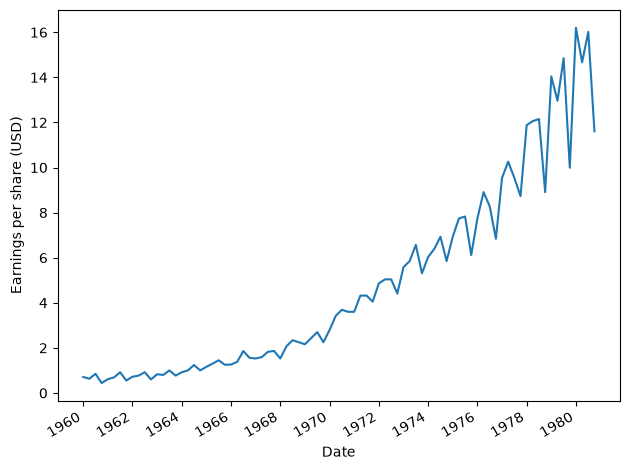

In [7]:
fig, ax = plt.subplots()

ax.plot(df.date, df['data'])
ax.set_xlabel('Date')
ax.set_ylabel('Earnings per share (USD)')

plt.xticks(np.arange(0, 81, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('figures/CH07_F02_peixeiro.png', dpi=300)

🧭 **Encontrar *d*:** aplicamos ADF, y si no es estacionaria diferenciamos y volvemos a probar, las veces que haga falta.

In [8]:
ad_fuller_result = adfuller(df['data'])

print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: 2.7420165734574735
p-value: 1.0


🔎 p-valor = 1.0 → no estacionaria.

In [9]:
eps_diff = np.diff(df['data'], n=1)

ad_fuller_result = adfuller(eps_diff)

print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: -0.40740976363804116
p-value: 0.9088542416911313


🔎 Con **una** diferencia: p ≈ 0.91 → todavía no estacionaria.

In [10]:
eps_diff2 = np.diff(eps_diff, n=1)

ad_fuller_result = adfuller(eps_diff2)

print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: -3.585162874793187
p-value: 0.006051099869603033


🔎 Con **dos** diferencias: p ≈ 0.006 < 0.05 → estacionaria. ✅ **Por tanto, d = 2.**

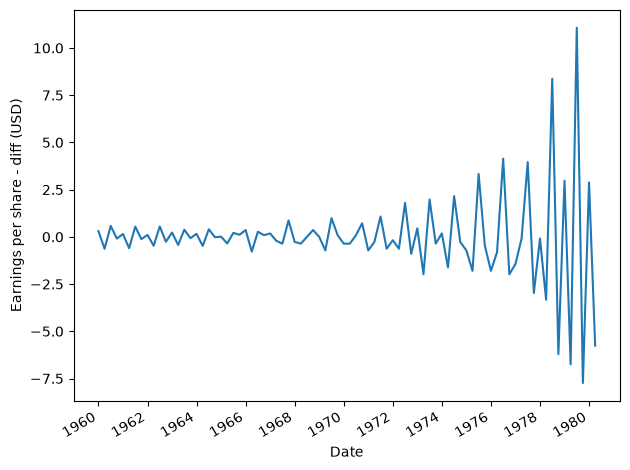

In [11]:
fig, ax = plt.subplots()

ax.plot(df['date'][2:], eps_diff2)
ax.set_xlabel('Date')
ax.set_ylabel('Earnings per share - diff (USD)')

plt.xticks(np.arange(0, 81, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

fig.autofmt_xdate()
plt.tight_layout()

# plt.savefig('figures/CH07_F01_peixeiro.png', dpi=300)

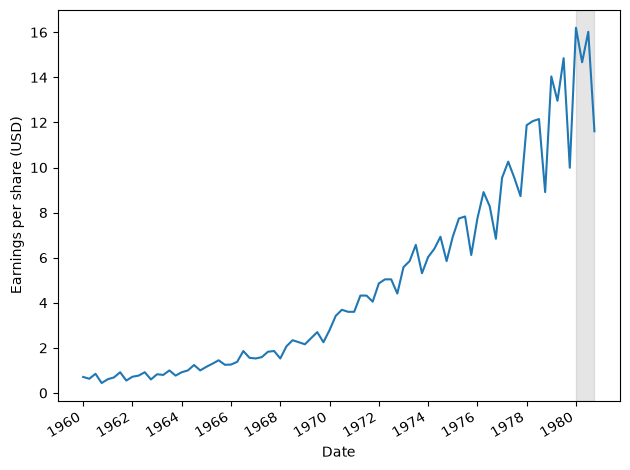

In [12]:
fig, ax = plt.subplots()

ax.plot(df.date, df.data)
ax.set_xlabel('Date')
ax.set_ylabel('Earnings per share (USD)')
ax.axvspan(80, 83, color='#808080', alpha=0.2)

plt.xticks(np.arange(0, 81, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('figures/CH07_F06_peixeiro.png', dpi=300)

🧭 Función que ajusta un ARIMA(p, d, q) para cada par (p, q) de la lista y devuelve una tabla ordenada por AIC (menor = mejor). `try/except` salta las combinaciones que no convergen.

In [13]:
def optimize_ARIMA(endog: Union[pd.Series, list], order_list: list, d: int) -> pd.DataFrame:
    
    results = []
    
    for order in tqdm_notebook(order_list):
        try: 
            model = SARIMAX(endog, order=(order[0], d, order[1]), simple_differencing=False).fit(disp=False)
        except:
            continue
            
        aic = model.aic
        results.append([order, aic])
        
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q)', 'AIC']
    
    #Sort in ascending order, lower AIC is better
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    
    return result_df

In [14]:
ps = range(0, 4, 1)
qs = range(0, 4, 1)
d = 2

order_list = list(product(ps, qs))

🧭 `train` = los primeros 80 trimestres (dejamos 1980 para el test, igual que en el notebook de baselines). Son 16 modelos pequeños: tarda pocos segundos.

In [15]:
train = df['data'][:-4]

result_df = optimize_ARIMA(train, order_list, d)
result_df

100%|██████████| 16/16 [00:00<00:00, 17.15it/s]


,"(p,q)",AIC
0,"(3, 3)",115.272663
1,"(3, 1)",115.624981
2,"(3, 2)",115.672008
3,"(3, 0)",154.430621
4,"(0, 3)",194.654716
5,"(0, 2)",209.274731
6,"(2, 3)",220.666967
7,"(1, 3)",228.267808
8,"(1, 2)",228.935808
9,"(2, 2)",229.974679


🔎 El menor AIC es **(p,q) = (3,3)** → modelo **ARIMA(3,2,3)**. Nota que (3,1) y (3,2) están muy cerca: en la práctica podríamos preferir el más simple si los residuos también son buenos.

🧭 Ajustamos el ganador, ARIMA(3,2,3), y vemos su resumen.

🔎 En el `summary()` fíjate en: `ar.L1…L3` (coeficientes φ), `ma.L1…L3` (coeficientes θ), `sigma2` (varianza del error) y el **AIC**. Para esta clase no hace falta interpretar cada coeficiente.

In [16]:
model = SARIMAX(train, order=(3,2,3), simple_differencing=False)
model_fit = model.fit(disp=False)

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                   data   No. Observations:                   80
Model:               SARIMAX(3, 2, 3)   Log Likelihood                 -50.636
Date:                Fri, 02 Oct 2026   AIC                            115.273
Time:                        14:41:34   BIC                            131.770
Sample:                             0   HQIC                           121.877
                                 - 80                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9985      0.037    -26.646      0.000      -1.072      -0.925
ar.L2         -0.9867      0.040    -24.675      0.000      -1.065      -0.908
ar.L3         -0.9751      0.026    -36.849      0.0

🔎 **Cómo leer los 4 paneles de `plot_diagnostics`** (queremos que los residuos parezcan **ruido blanco**, es decir, error puramente aleatorio):
1. **Residuos estandarizados (arriba izq.):** deben oscilar alrededor de 0, sin tendencia y con varianza más o menos constante.
2. **Histograma + densidad (arriba der.):** debe parecerse a la campana normal (línea N(0,1)).
3. **Q-Q plot (abajo izq.):** los puntos deben caer sobre la línea roja diagonal. Si se curvan en los extremos, los residuos no son normales.
4. **Correlograma / ACF (abajo der.):** ninguna barra (salvo la del rezago 0) debe salir de la zona azul.

💡 Analogía: si el modelo es bueno, lo que “sobra” (los residuos) debe ser como el ruido de estática de un radio: no queda ninguna melodía escondida que el modelo no haya escuchado.

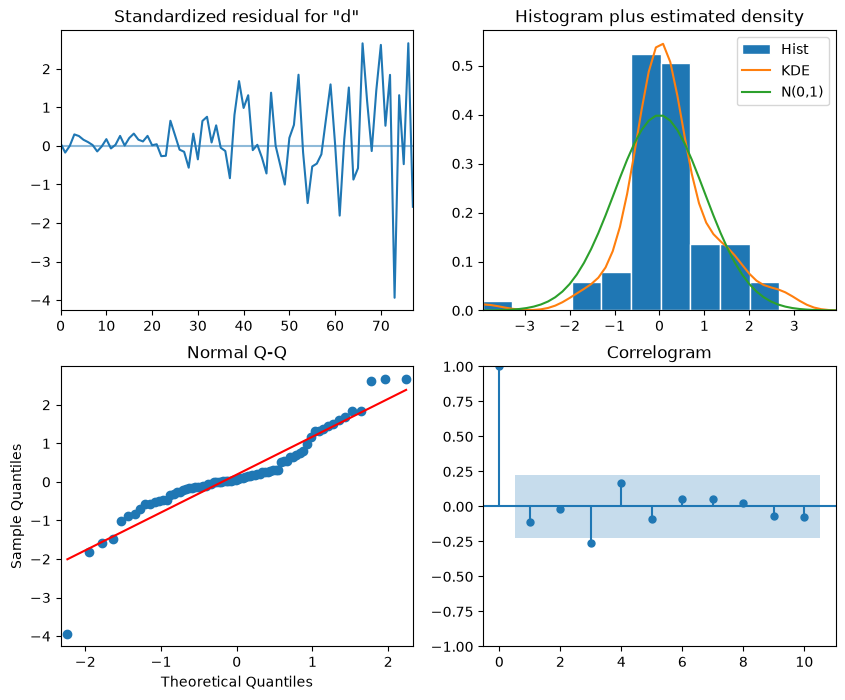

In [17]:
model_fit.plot_diagnostics(figsize=(10,8));

plt.savefig('figures/CH07_F07_peixeiro.png', dpi=300)

🛠️ **Cambio respecto al libro — prueba de Ljung-Box.** En versiones recientes de `statsmodels`, `acorr_ljungbox` devuelve una **tabla** (DataFrame) y no dos listas. El código original (`lbvalue, pvalue = acorr_ljungbox(...)`) ya no falla, pero imprime solo el texto `lb_pvalue` en lugar de los números: un error silencioso. Aquí guardamos la tabla completa y mostramos la columna de p-valores.

In [18]:
residuals = model_fit.resid

# 🛠️ Versión actualizada (statsmodels >= 0.13 devuelve un DataFrame)
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_df = acorr_ljungbox(residuals, lags=np.arange(1, 11, 1), return_df=True)

print(lb_df['lb_pvalue'])
print('\n¿Todos los p-valores > 0.05?', (lb_df['lb_pvalue'] > 0.05).all())

1     0.196519
2     0.434143
3     0.062500
4     0.054216
5     0.077549
6     0.118656
7     0.167409
8     0.236209
9     0.291536
10    0.340091
Name: lb_pvalue, dtype: float64

¿Todos los p-valores > 0.05? True


🔎 **Cómo leer Ljung-Box.** Hipótesis nula (H0): *los residuos NO están correlacionados* (son ruido blanco).
- **p-valor > 0.05 en todos los rezagos** → no rechazamos H0 → los residuos parecen ruido blanco → ✅ el modelo capturó la información útil.
- p-valor < 0.05 en algún rezago → queda estructura sin explicar → conviene probar otro orden del modelo.

⚠️ Ojo: aquí **queremos p-valores ALTOS**, al revés que en la prueba ADF (donde queremos p-valores bajos para declarar estacionariedad).

🧭 Reconstruimos el test (4 trimestres de 1980) con el baseline **naive estacional** (valores de 1979) para comparar.

In [19]:
test = df.iloc[-4:]

test['naive_seasonal'] = df['data'].iloc[76:80].values
test

,date,data,naive_seasonal
80,1980-01-01,16.20,14.04
81,1980-04-01,14.67,12.96
82,1980-07-02,16.02,14.85
83,1980-10-01,11.61,9.99


🧭 `get_prediction(80, 83)` pide las predicciones de los índices 80 a 83, es decir, **los 4 trimestres de 1980**, ya en la escala original de EPS.

In [20]:
ARIMA_pred = model_fit.get_prediction(80, 83).predicted_mean

test['ARIMA_pred'] = ARIMA_pred
test

,date,data,naive_seasonal,ARIMA_pred
80,1980-01-01,16.20,14.04,15.855507
81,1980-04-01,14.67,12.96,14.380541
82,1980-07-02,16.02,14.85,16.369692
83,1980-10-01,11.61,9.99,11.684409


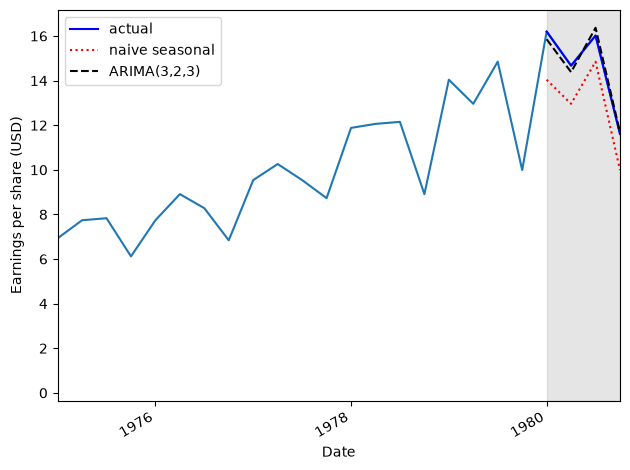

In [21]:
fig, ax = plt.subplots()

ax.plot(df['date'], df['data'])
ax.plot(test['data'], 'b-', label='actual')
ax.plot(test['naive_seasonal'], 'r:', label='naive seasonal')
ax.plot(test['ARIMA_pred'], 'k--', label='ARIMA(3,2,3)')

ax.set_xlabel('Date')
ax.set_ylabel('Earnings per share (USD)')
ax.axvspan(80, 83, color='#808080', alpha=0.2)

ax.legend(loc=2)

plt.xticks(np.arange(0, 81, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])
ax.set_xlim(60, 83)

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('figures/CH07_F08_peixeiro.png', dpi=300)

In [22]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [23]:
mape_naive_seasonal = mape(test['data'], test['naive_seasonal'])
mape_ARIMA = mape(test['data'], test['ARIMA_pred'])

print(mape_naive_seasonal, mape_ARIMA)

11.561658552433654 1.7308473667949693


🔎 **Naive estacional ≈ 11.6 %** vs. **ARIMA(3,2,3) ≈ 1.7 %**. El ARIMA reduce el error **unas 7 veces** respecto al mejor baseline.

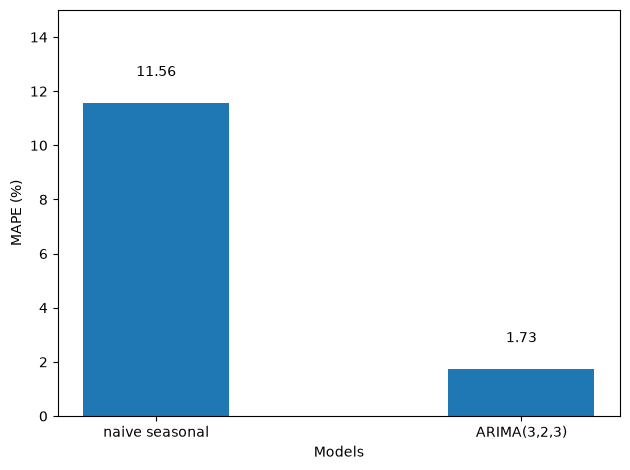

In [24]:
fig, ax = plt.subplots()

x = ['naive seasonal', 'ARIMA(3,2,3)']
y = [mape_naive_seasonal, mape_ARIMA]

ax.bar(x, y, width=0.4)
ax.set_xlabel('Models')
ax.set_ylabel('MAPE (%)')
ax.set_ylim(0, 15)

for index, value in enumerate(y):
    plt.text(x=index, y=value + 1, s=str(round(value,2)), ha='center')

plt.tight_layout()

plt.savefig('figures/CH07_F09_peixeiro.png', dpi=300)

---
## ✅ Resumen
- La **I** de ARIMA = diferenciar *d* veces dentro del modelo; *d* se encuentra con ADF sucesivas.
- Procedimiento: ADF → *d* → malla de (p, q) → menor AIC → residuos (Q-Q, Ljung-Box) → pronóstico → comparar contra baseline.
- En J&J: **11.6 % → 1.7 %** de MAPE.

🤔 **Pregunta para la próxima sección:** esta serie tiene un patrón que se repite cada año y el ARIMA no lo modela *explícitamente*. ¿Podemos hacerlo mejor diciéndole al modelo que existe esa estacionalidad? → **SARIMA** (Capítulo 8).

### 🏠 Ejercicios para casa
`CH07_exercises_solution.ipynb`: repite el procedimiento con otra partición train/test y con el MAE como métrica.

### 🧠 Autoevaluación
- Si una serie necesita dos diferencias para ser estacionaria, ¿cuánto vale *d*?
- ¿Por qué con ARIMA no hace falta invertir la diferenciación a mano?
